In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import seaborn as sns

In [2]:
iris = load_iris()
X = iris.data  # Features
feature_names = iris.feature_names

In [3]:
# Create a DataFrame for better visualization
df = pd.DataFrame(X, columns=feature_names)
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

Dataset shape: (150, 4)

First few rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [4]:
# Standardize the features (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


ELBOW METHOD - Finding Optimal K
K=2: WCSS = 222.36
K=3: WCSS = 139.82
K=4: WCSS = 114.09
K=5: WCSS = 90.93
K=6: WCSS = 81.54
K=7: WCSS = 72.63
K=8: WCSS = 62.54
K=9: WCSS = 55.12
K=10: WCSS = 47.39


FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/elbow_method.png'

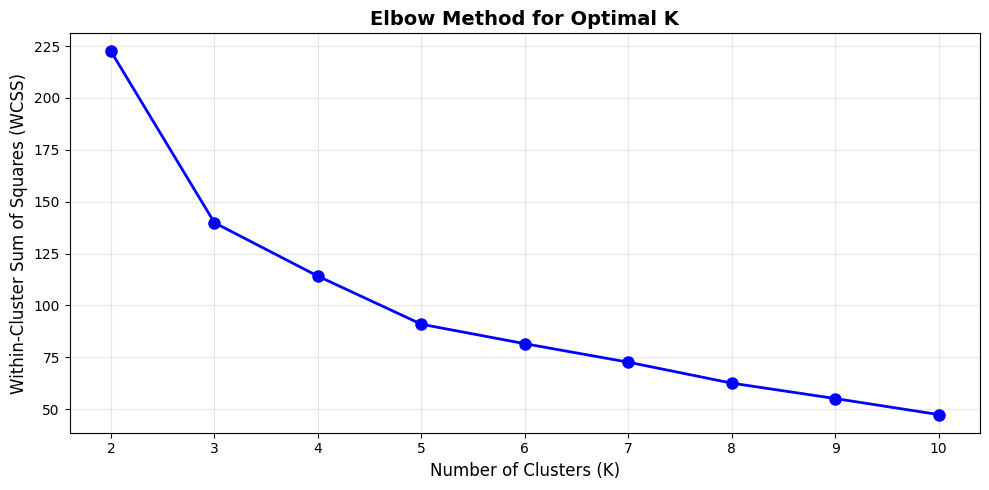

In [5]:
# ========================================
# ELBOW METHOD
# ========================================
print("\n" + "="*50)
print("ELBOW METHOD - Finding Optimal K")
print("="*50)

wcss = []  # Within-Cluster Sum of Squares
K_range = range(2, 11)  # Test K from 2 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # inertia_ is the WCSS
    print(f"K={k}: WCSS = {kmeans.inertia_:.2f}")

# Plot Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.savefig('/home/claude/elbow_method.png', dpi=300, bbox_inches='tight')
print("\nElbow plot saved!")


SILHOUETTE SCORE METHOD - Finding Optimal K
K=2: Silhouette Score = 0.5818
K=3: Silhouette Score = 0.4599
K=4: Silhouette Score = 0.3869
K=5: Silhouette Score = 0.3459
K=6: Silhouette Score = 0.3171
K=7: Silhouette Score = 0.3202
K=8: Silhouette Score = 0.3387
K=9: Silhouette Score = 0.3424
K=10: Silhouette Score = 0.3518


FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/silhouette_scores.png'

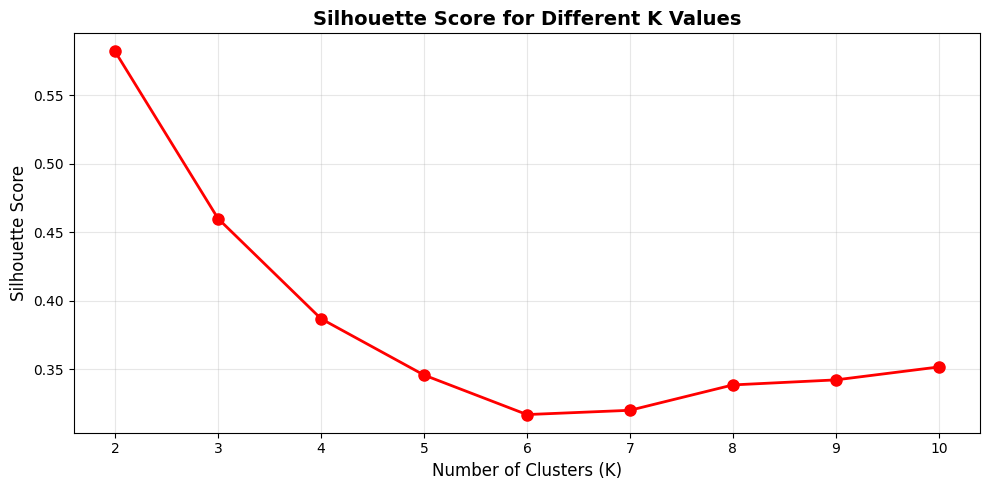

In [6]:
# ========================================
# SILHOUETTE SCORE METHOD
# ========================================
print("\n" + "="*50)
print("SILHOUETTE SCORE METHOD - Finding Optimal K")
print("="*50)

silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"K={k}: Silhouette Score = {silhouette_avg:.4f}")

# Plot Silhouette Scores
plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score for Different K Values', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.savefig('/home/claude/silhouette_scores.png', dpi=300, bbox_inches='tight')
print("\nSilhouette score plot saved!")



FINAL CLUSTERING with K=2

Cluster distribution:
Cluster
0    100
1     50
Name: count, dtype: int64


FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/clustering_comparison.png'

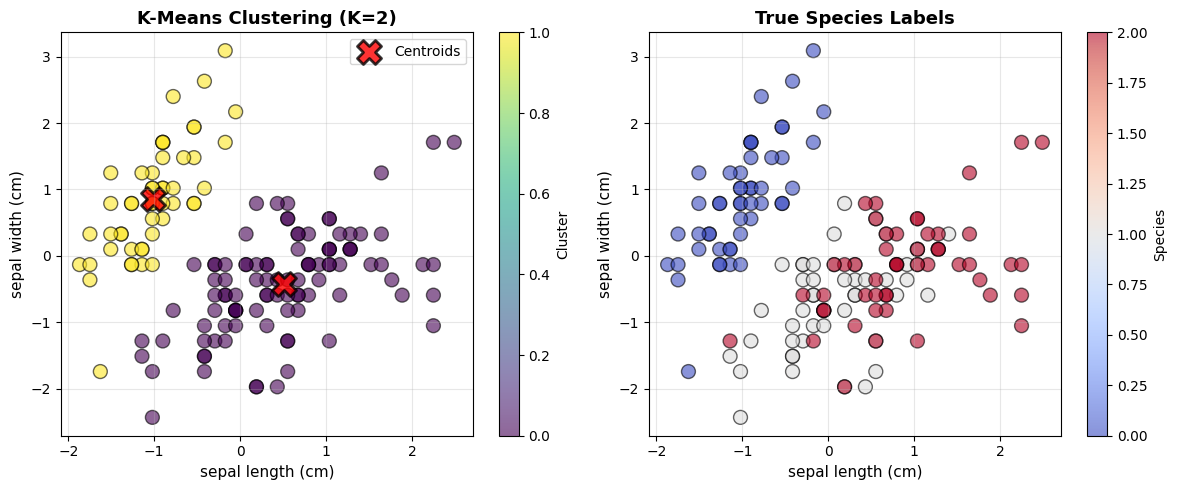

In [7]:
# ========================================
# FINAL CLUSTERING with Optimal K
# ========================================
optimal_k = K_range[np.argmax(silhouette_scores)]
print("\n" + "="*50)
print(f"FINAL CLUSTERING with K={optimal_k}")
print("="*50)

# Perform final clustering
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = final_kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['Cluster'] = clusters
df['True_Species'] = iris.target

print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

# Visualize clusters (using first 2 features for 2D plot)
plt.figure(figsize=(12, 5))

# Subplot 1: Clusters
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
                     c=clusters, cmap='viridis',
                     s=100, alpha=0.6, edgecolors='black')
plt.scatter(final_kmeans.cluster_centers_[:, 0],
           final_kmeans.cluster_centers_[:, 1],
           c='red', s=300, alpha=0.8, marker='X',
           edgecolors='black', linewidths=2, label='Centroids')
plt.xlabel(feature_names[0], fontsize=11)
plt.ylabel(feature_names[1], fontsize=11)
plt.title(f'K-Means Clustering (K={optimal_k})', fontsize=13, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: True Species
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
                      c=iris.target, cmap='coolwarm',
                      s=100, alpha=0.6, edgecolors='black')
plt.xlabel(feature_names[0], fontsize=11)
plt.ylabel(feature_names[1], fontsize=11)
plt.title('True Species Labels', fontsize=13, fontweight='bold')
plt.colorbar(scatter2, label='Species')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/claude/clustering_comparison.png', dpi=300, bbox_inches='tight')
print("\nClustering visualization saved!")

# Summary Statistics
print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Optimal K by Silhouette Score: {optimal_k}")
print(f"Final Silhouette Score: {silhouette_scores[optimal_k-2]:.4f}")
print(f"Final WCSS: {wcss[optimal_k-2]:.2f}")

plt.show()

In [ ]:
# Example 2 K Mean

In [ ]:
davies_bouldin_scores
calinski_harabasz_scores

In [8]:
import os
os.getcwd()

'/content'

ADVANCED K-MEANS CLUSTERING ANALYSIS
Customer Segmentation for Marketing Strategy

STEP 1: DATA LOADING AND EXPLORATION
Dataset shape: (1000, 12)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Age                     1000 non-null   int64  
 2   Annual_Income           1000 non-null   float64
 3   Spending_Score          1000 non-null   float64
 4   Years_Customer          1000 non-null   int64  
 5   Purchase_Frequency      1000 non-null   float64
 6   Average_Transaction     1000 non-null   float64
 7   Online_Purchases_Ratio  1000 non-null   float64
 8   Email_Click_Rate        1000 non-null   float64
 9   Support_Tickets         1000 non-null   int64  
 10  Product_Categories      1000 non-null   int64  
 11  Loyalty_Points          1000 non-null  

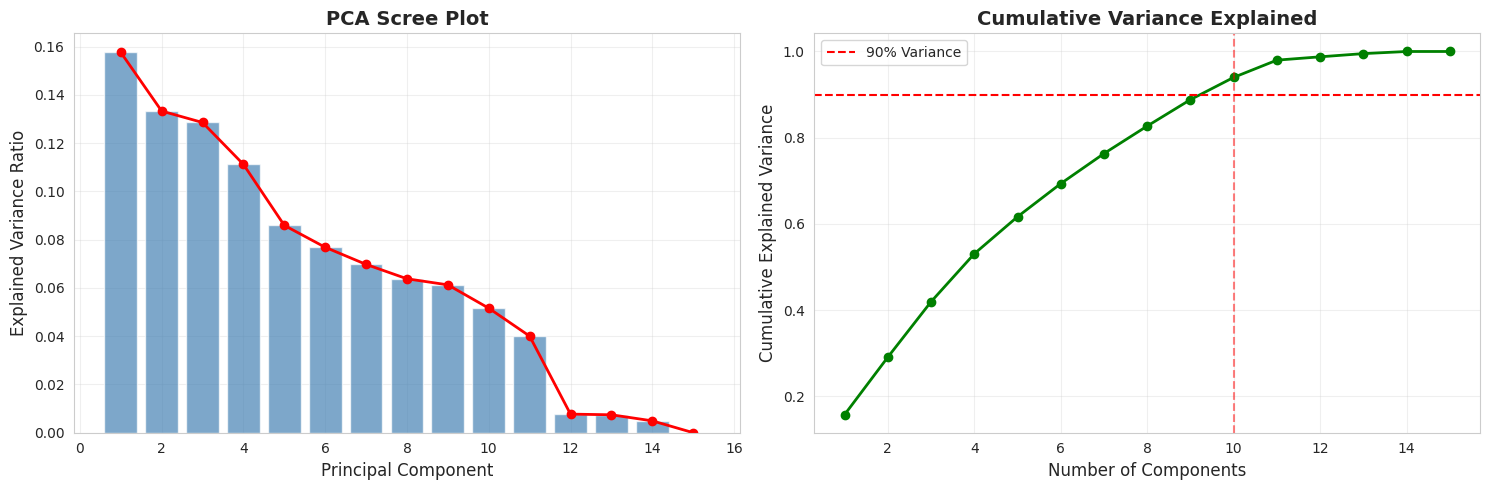

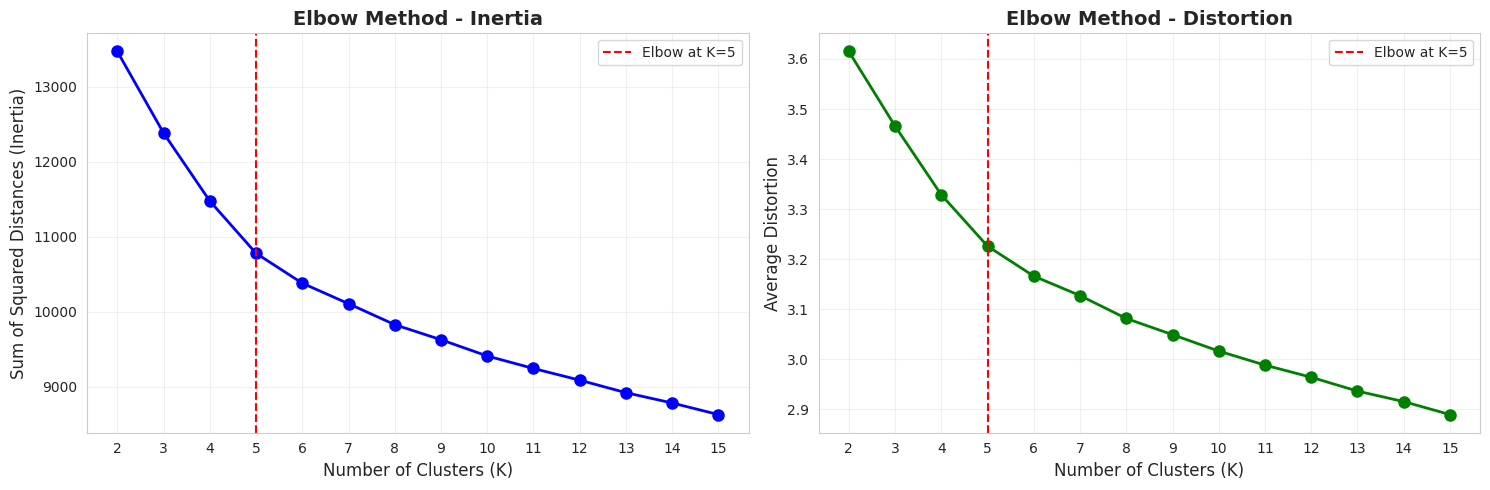

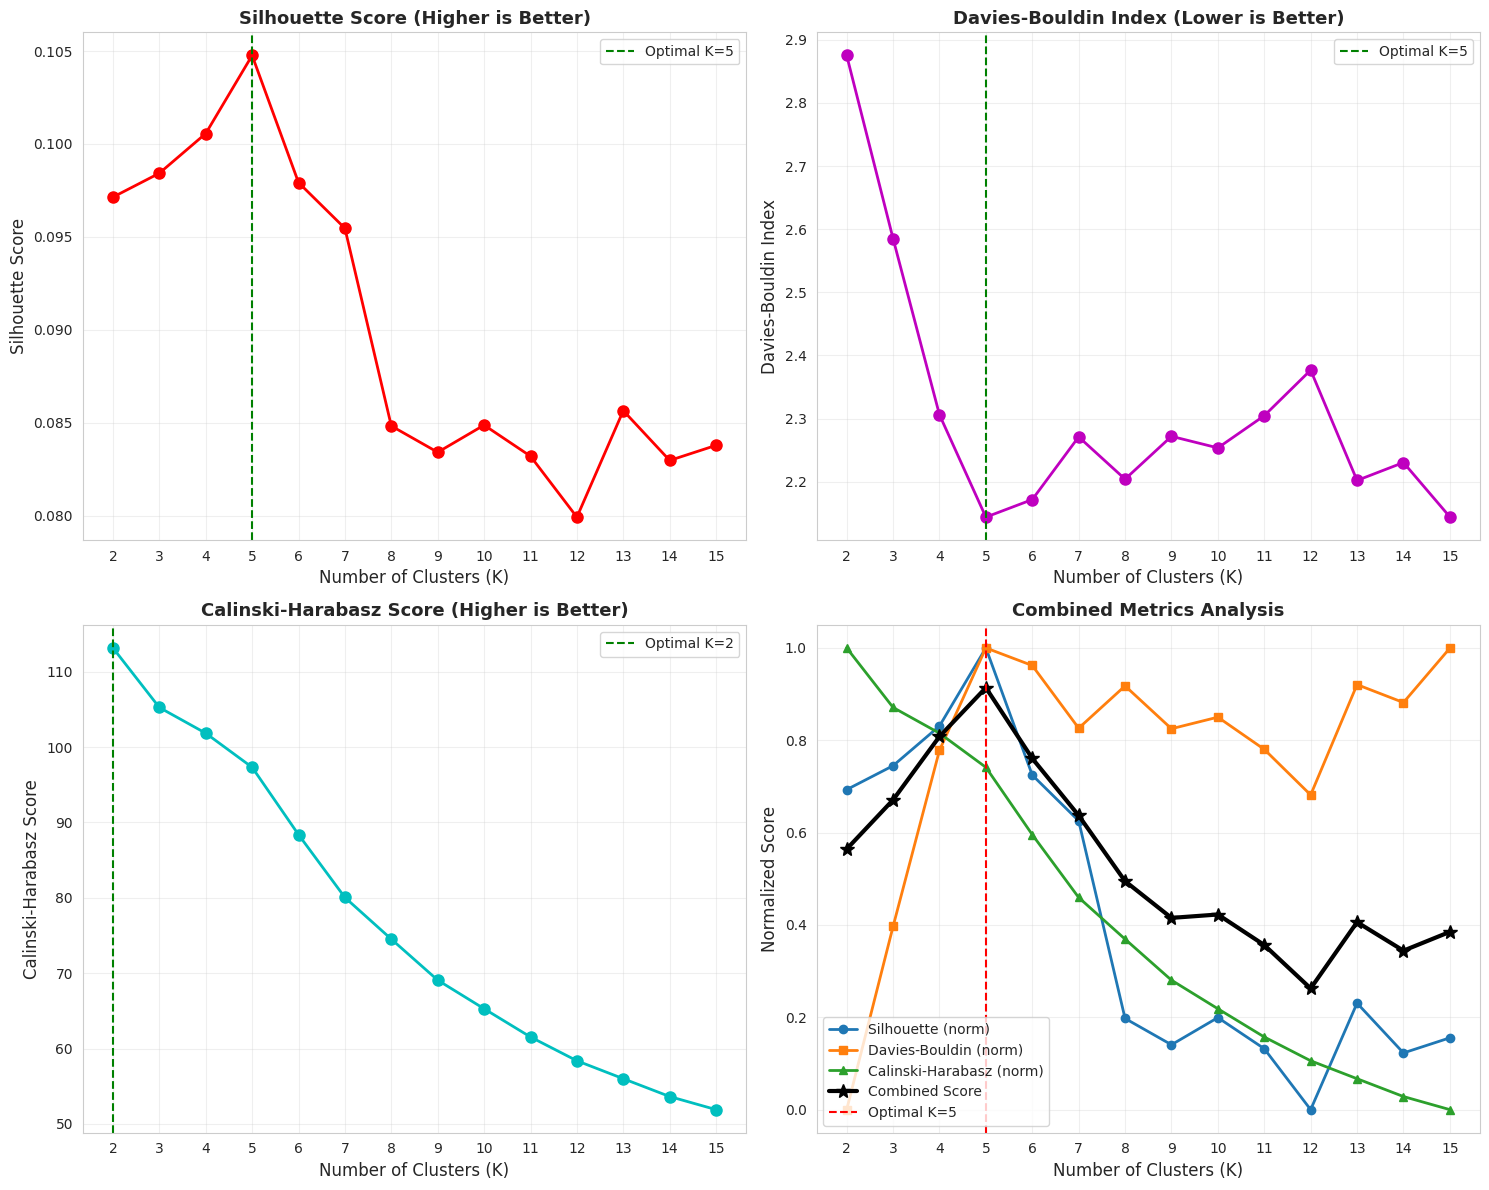

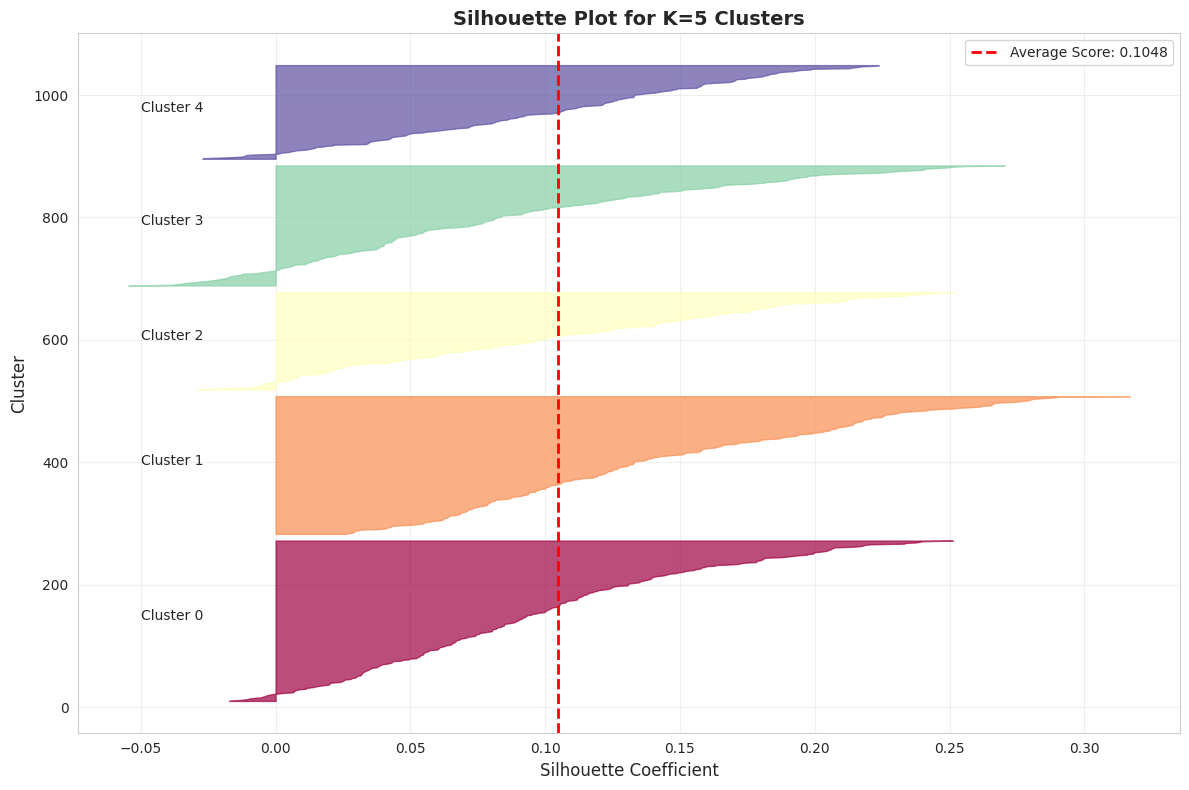

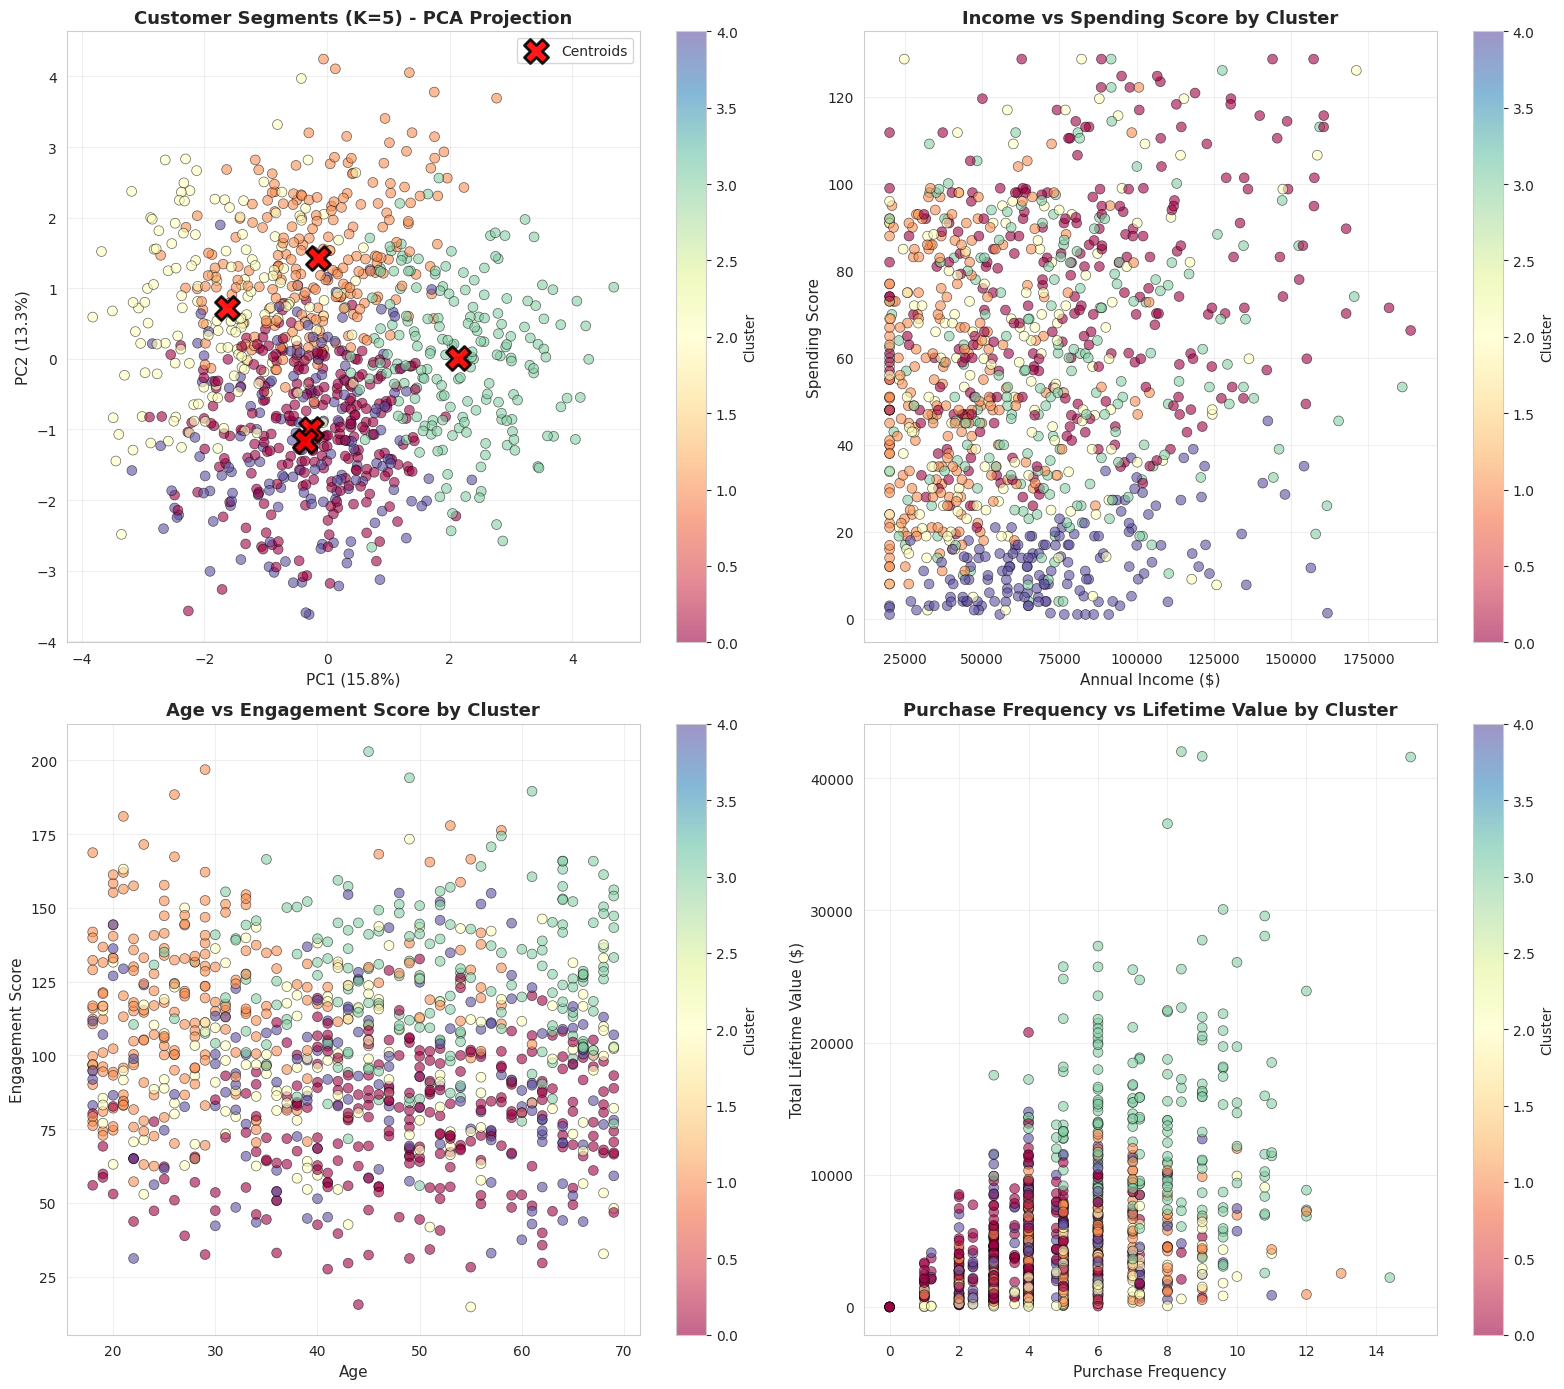

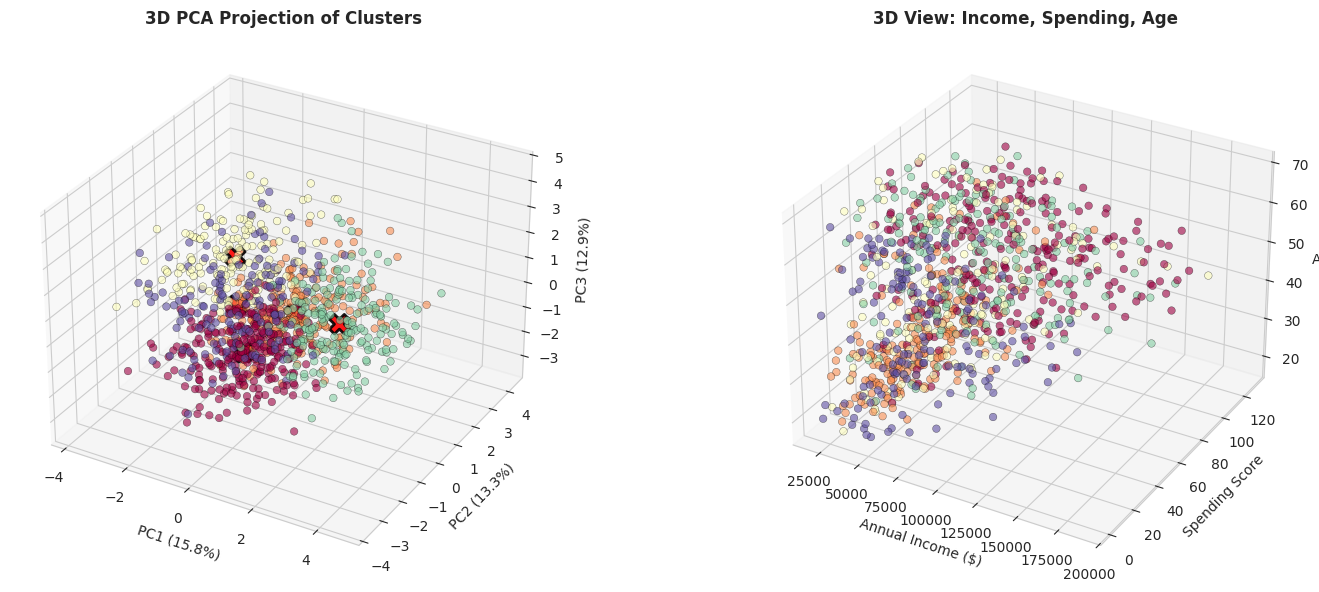

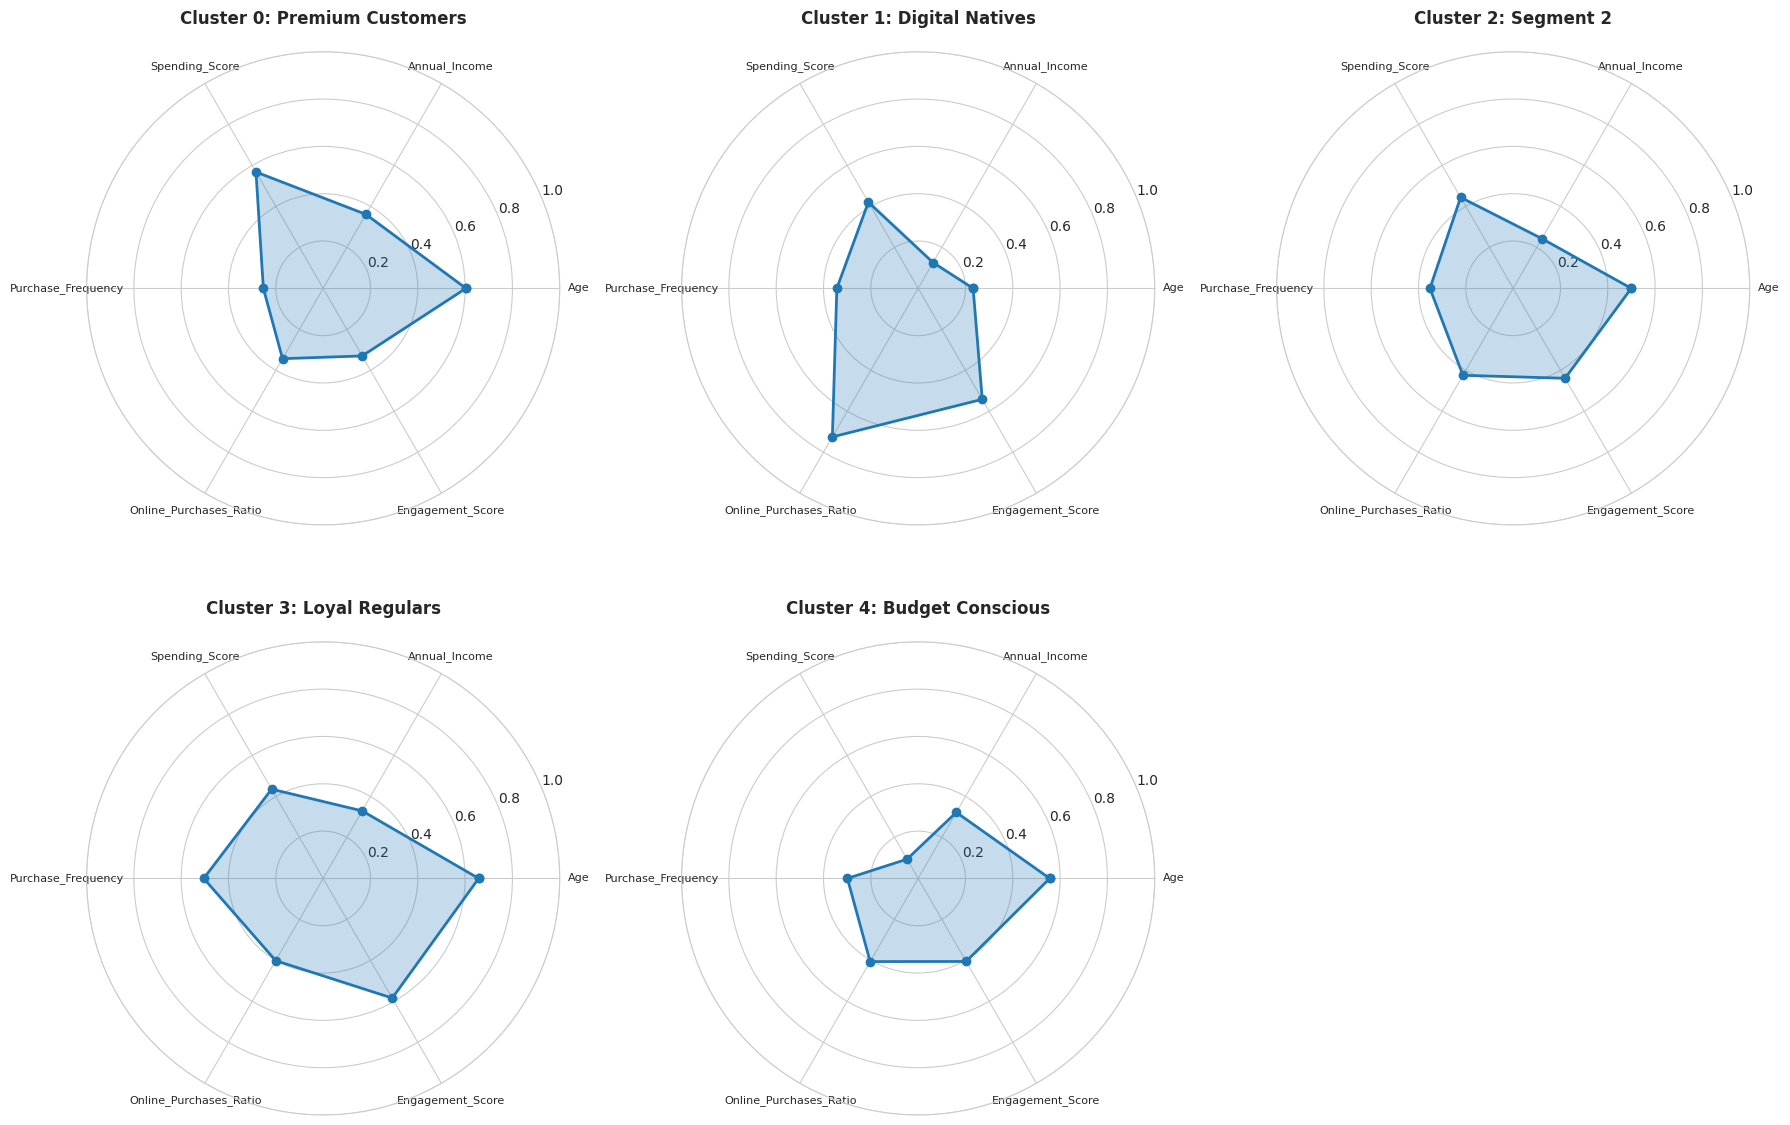

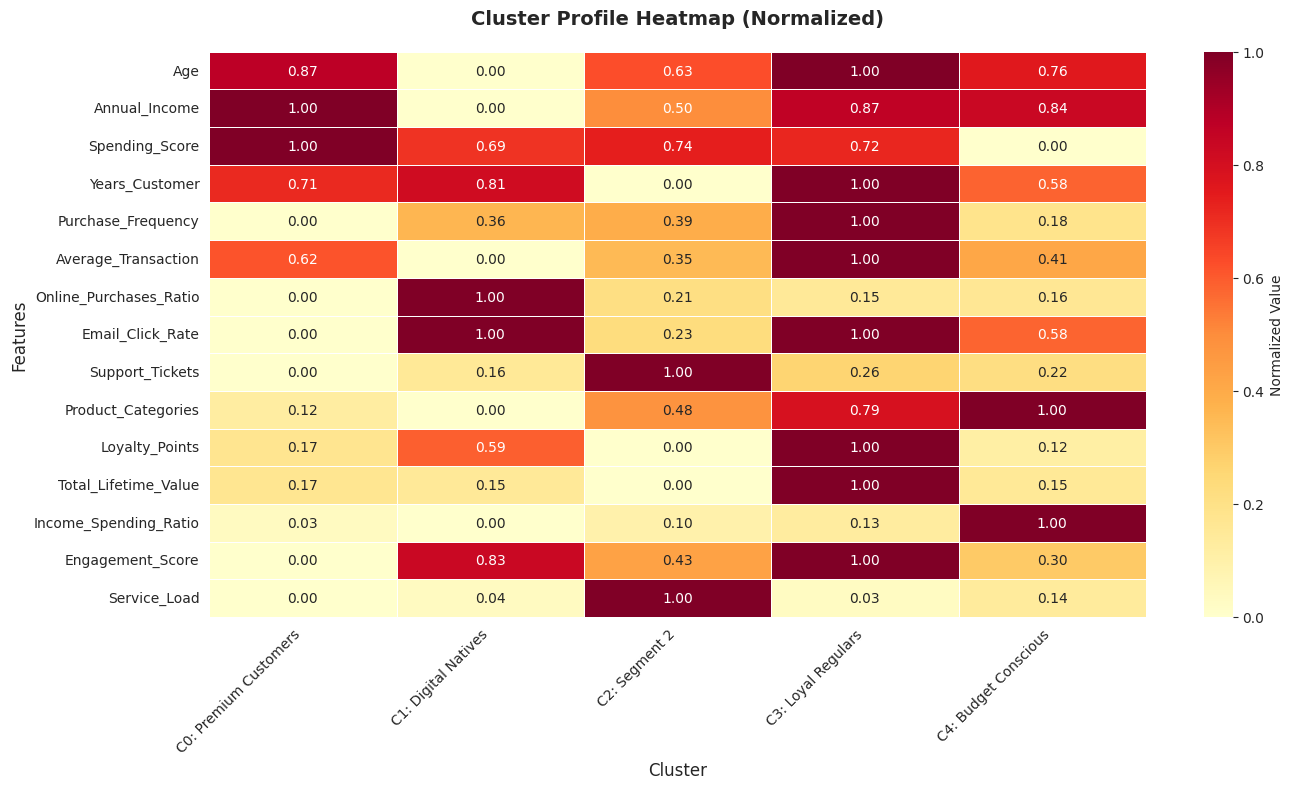

In [9]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

print("="*80)
print("ADVANCED K-MEANS CLUSTERING ANALYSIS")
print("Customer Segmentation for Marketing Strategy")
print("="*80)

# ========================================
# 1. LOAD AND EXPLORE DATA
# ========================================
print("\n" + "="*80)
print("STEP 1: DATA LOADING AND EXPLORATION")
print("="*80)

# Create synthetic customer data (realistic e-commerce dataset)
np.random.seed(42)
n_customers = 1000

# Generate customer features
data = {
    'CustomerID': range(1, n_customers + 1),
    'Age': np.random.randint(18, 70, n_customers),
    'Annual_Income': np.random.normal(60000, 25000, n_customers),
    'Spending_Score': np.random.randint(1, 100, n_customers),
    'Years_Customer': np.random.randint(1, 15, n_customers),
    'Purchase_Frequency': np.random.poisson(5, n_customers),
    'Average_Transaction': np.random.normal(150, 75, n_customers),
    'Online_Purchases_Ratio': np.random.uniform(0, 1, n_customers),
    'Email_Click_Rate': np.random.uniform(0, 0.5, n_customers),
    'Support_Tickets': np.random.poisson(2, n_customers),
    'Product_Categories': np.random.randint(1, 10, n_customers),
    'Loyalty_Points': np.random.randint(0, 5000, n_customers)
}

df = pd.DataFrame(data)

# Add some realistic patterns (create customer segments)
# Segment 1: Young, low income, high online activity
mask1 = (df['Age'] < 30)
df.loc[mask1, 'Annual_Income'] *= 0.6
df.loc[mask1, 'Online_Purchases_Ratio'] *= 1.3
df.loc[mask1, 'Average_Transaction'] *= 0.7

# Segment 2: Middle-aged, high income, high spending
mask2 = (df['Age'] >= 40) & (df['Age'] < 55)
df.loc[mask2, 'Annual_Income'] *= 1.5
df.loc[mask2, 'Spending_Score'] *= 1.3
df.loc[mask2, 'Average_Transaction'] *= 1.4

# Segment 3: Seniors, moderate spending, low online
mask3 = (df['Age'] >= 60)
df.loc[mask3, 'Online_Purchases_Ratio'] *= 0.5
df.loc[mask3, 'Purchase_Frequency'] *= 1.2

# Clean data
df['Annual_Income'] = df['Annual_Income'].clip(lower=20000, upper=200000)
df['Online_Purchases_Ratio'] = df['Online_Purchases_Ratio'].clip(upper=1)
df['Average_Transaction'] = df['Average_Transaction'].clip(lower=10)

print(f"Dataset shape: {df.shape}")
print(f"\nDataset Info:")
print(df.info())
print(f"\nStatistical Summary:")
print(df.describe().round(2))

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

# ========================================
# 2. FEATURE ENGINEERING
# ========================================
print("\n" + "="*80)
print("STEP 2: FEATURE ENGINEERING")
print("="*80)

# Create new features
df['Total_Lifetime_Value'] = df['Average_Transaction'] * df['Purchase_Frequency'] * df['Years_Customer']
df['Income_Spending_Ratio'] = df['Annual_Income'] / (df['Spending_Score'] + 1)
df['Engagement_Score'] = (df['Email_Click_Rate'] * 100 +
                          df['Online_Purchases_Ratio'] * 50 +
                          df['Purchase_Frequency'] * 10)
df['Service_Load'] = df['Support_Tickets'] / (df['Years_Customer'] + 1)

print("New features created:")
print("- Total_Lifetime_Value: Revenue potential")
print("- Income_Spending_Ratio: Financial behavior indicator")
print("- Engagement_Score: Customer engagement metric")
print("- Service_Load: Support intensity")

# Select features for clustering
feature_cols = ['Age', 'Annual_Income', 'Spending_Score', 'Years_Customer',
                'Purchase_Frequency', 'Average_Transaction', 'Online_Purchases_Ratio',
                'Email_Click_Rate', 'Support_Tickets', 'Product_Categories',
                'Loyalty_Points', 'Total_Lifetime_Value', 'Income_Spending_Ratio',
                'Engagement_Score', 'Service_Load']

X = df[feature_cols].copy()
print(f"\nFeatures for clustering: {len(feature_cols)}")

# ========================================
# 3. DATA PREPROCESSING
# ========================================
print("\n" + "="*80)
print("STEP 3: DATA PREPROCESSING")
print("="*80)

# Handle outliers using IQR method
def remove_outliers(data, columns, threshold=1.5):
    data_clean = data.copy()
    for col in columns:
        Q1 = data_clean[col].quantile(0.25)
        Q3 = data_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        data_clean[col] = data_clean[col].clip(lower=lower_bound, upper=upper_bound)
    return data_clean

X_clean = remove_outliers(X, feature_cols)
print("Outliers handled using IQR method")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print(f"Features standardized (mean=0, std=1)")
print(f"\nScaled data summary:")
print(X_scaled_df.describe().round(2))

# ========================================
# 4. DIMENSIONALITY REDUCTION (PCA)
# ========================================
print("\n" + "="*80)
print("STEP 4: DIMENSIONALITY REDUCTION WITH PCA")
print("="*80)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print(f"Original dimensions: {X_scaled.shape[1]}")
print(f"\nExplained variance by component:")
for i, (var, cum_var) in enumerate(zip(explained_var[:5], cumulative_var[:5]), 1):
    print(f"PC{i}: {var*100:.2f}% (Cumulative: {cum_var*100:.2f}%)")

# Find number of components for 90% variance
n_components_90 = np.argmax(cumulative_var >= 0.90) + 1
print(f"\nComponents needed for 90% variance: {n_components_90}")

# Plot variance explained
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot
axes[0].bar(range(1, len(explained_var) + 1), explained_var, alpha=0.7, color='steelblue')
axes[0].plot(range(1, len(explained_var) + 1), explained_var, 'o-', color='red', linewidth=2)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('PCA Scree Plot', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var, 'o-', color='green', linewidth=2)
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90% Variance')
axes[1].axvline(x=n_components_90, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/contentpca_analysis.png', dpi=300, bbox_inches='tight')
print("\nPCA analysis saved!")

# ========================================
# 5. ELBOW METHOD (Enhanced)
# ========================================
print("\n" + "="*80)
print("STEP 5: ELBOW METHOD ANALYSIS")
print("="*80)

K_range = range(2, 16)
inertias = []
distortions = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    distortions.append(sum(np.min(cdist(X_scaled, kmeans.cluster_centers_, 'euclidean'), axis=1)) / X_scaled.shape[0])
    print(f"K={k:2d}: Inertia={kmeans.inertia_:10.2f}, Distortion={distortions[-1]:.4f}")

# Calculate rate of change to find elbow
inertia_diff = np.diff(inertias)
inertia_diff_2 = np.diff(inertia_diff)
elbow_k = np.argmax(inertia_diff_2) + 3  # +3 because of two diffs and 0-indexing

print(f"\nSuggested elbow point: K={elbow_k}")

# Plot elbow curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Inertia plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=elbow_k, color='red', linestyle='--', label=f'Elbow at K={elbow_k}')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Sum of Squared Distances (Inertia)', fontsize=12)
axes[0].set_title('Elbow Method - Inertia', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(K_range)

# Distortion plot
axes[1].plot(K_range, distortions, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=elbow_k, color='red', linestyle='--', label=f'Elbow at K={elbow_k}')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Average Distortion', fontsize=12)
axes[1].set_title('Elbow Method - Distortion', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(K_range)

plt.tight_layout()
plt.savefig('/contentelbow_method_advanced.png', dpi=300, bbox_inches='tight')
print("Elbow method plots saved!")

# ========================================
# 6. SILHOUETTE ANALYSIS (Comprehensive)
# ========================================
print("\n" + "="*80)
print("STEP 6: COMPREHENSIVE SILHOUETTE ANALYSIS")
print("="*80)

silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)

    sil_score = silhouette_score(X_scaled, labels)
    db_score = davies_bouldin_score(X_scaled, labels)
    ch_score = calinski_harabasz_score(X_scaled, labels)

    silhouette_scores.append(sil_score)
    davies_bouldin_scores.append(db_score)
    calinski_harabasz_scores.append(ch_score)

    print(f"K={k:2d}: Silhouette={sil_score:.4f}, Davies-Bouldin={db_score:.4f}, Calinski-Harabasz={ch_score:.2f}")

optimal_k_silhouette = K_range[np.argmax(silhouette_scores)]
optimal_k_db = K_range[np.argmin(davies_bouldin_scores)]  # Lower is better
optimal_k_ch = K_range[np.argmax(calinski_harabasz_scores)]  # Higher is better

print(f"\nOptimal K by Silhouette Score: {optimal_k_silhouette}")
print(f"Optimal K by Davies-Bouldin Index: {optimal_k_db}")
print(f"Optimal K by Calinski-Harabasz Index: {optimal_k_ch}")

# Plot all metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Silhouette Score
axes[0, 0].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[0, 0].axvline(x=optimal_k_silhouette, color='green', linestyle='--',
                   label=f'Optimal K={optimal_k_silhouette}')
axes[0, 0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0, 0].set_ylabel('Silhouette Score', fontsize=12)
axes[0, 0].set_title('Silhouette Score (Higher is Better)', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(K_range)

# Davies-Bouldin Index
axes[0, 1].plot(K_range, davies_bouldin_scores, 'mo-', linewidth=2, markersize=8)
axes[0, 1].axvline(x=optimal_k_db, color='green', linestyle='--',
                   label=f'Optimal K={optimal_k_db}')
axes[0, 1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0, 1].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[0, 1].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(K_range)

# Calinski-Harabasz Score
axes[1, 0].plot(K_range, calinski_harabasz_scores, 'co-', linewidth=2, markersize=8)
axes[1, 0].axvline(x=optimal_k_ch, color='green', linestyle='--',
                   label=f'Optimal K={optimal_k_ch}')
axes[1, 0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1, 0].set_ylabel('Calinski-Harabasz Score', fontsize=12)
axes[1, 0].set_title('Calinski-Harabasz Score (Higher is Better)', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(K_range)

# Combined normalized scores
norm_sil = (np.array(silhouette_scores) - min(silhouette_scores)) / (max(silhouette_scores) - min(silhouette_scores))
norm_db = 1 - ((np.array(davies_bouldin_scores) - min(davies_bouldin_scores)) /
               (max(davies_bouldin_scores) - min(davies_bouldin_scores)))
norm_ch = (np.array(calinski_harabasz_scores) - min(calinski_harabasz_scores)) / \
          (max(calinski_harabasz_scores) - min(calinski_harabasz_scores))

combined_score = (norm_sil + norm_db + norm_ch) / 3
optimal_k_combined = K_range[np.argmax(combined_score)]

axes[1, 1].plot(K_range, norm_sil, 'o-', label='Silhouette (norm)', linewidth=2)
axes[1, 1].plot(K_range, norm_db, 's-', label='Davies-Bouldin (norm)', linewidth=2)
axes[1, 1].plot(K_range, norm_ch, '^-', label='Calinski-Harabasz (norm)', linewidth=2)
axes[1, 1].plot(K_range, combined_score, 'k*-', label='Combined Score', linewidth=3, markersize=10)
axes[1, 1].axvline(x=optimal_k_combined, color='red', linestyle='--',
                   label=f'Optimal K={optimal_k_combined}')
axes[1, 1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1, 1].set_ylabel('Normalized Score', fontsize=12)
axes[1, 1].set_title('Combined Metrics Analysis', fontsize=13, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(K_range)

plt.tight_layout()
plt.savefig('/contentclustering_metrics.png', dpi=300, bbox_inches='tight')
print("\nClustering metrics plots saved!")

# ========================================
# 7. SILHOUETTE PLOT FOR OPTIMAL K
# ========================================
print("\n" + "="*80)
print("STEP 7: DETAILED SILHOUETTE ANALYSIS FOR OPTIMAL K")
print("="*80)

# Use the combined optimal K
optimal_k = optimal_k_combined
print(f"Using K={optimal_k} for detailed analysis")

kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=20, max_iter=300)
cluster_labels = kmeans_optimal.fit_predict(X_scaled)

# Calculate silhouette scores for each sample
silhouette_vals = silhouette_samples(X_scaled, cluster_labels)

# Create silhouette plot
fig, ax = plt.subplots(figsize=(12, 8))

y_lower = 10
colors = plt.cm.Spectral(np.linspace(0, 1, optimal_k))

for i in range(optimal_k):
    # Aggregate silhouette scores for samples in cluster i
    cluster_silhouette_vals = silhouette_vals[cluster_labels == i]
    cluster_silhouette_vals.sort()

    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.7)

    # Label clusters
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, f'Cluster {i}')
    y_lower = y_upper + 10

ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title(f'Silhouette Plot for K={optimal_k} Clusters', fontsize=14, fontweight='bold')

# Vertical line for average silhouette score
avg_score = silhouette_score(X_scaled, cluster_labels)
ax.axvline(x=avg_score, color='red', linestyle='--', linewidth=2,
           label=f'Average Score: {avg_score:.4f}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/contentsilhouette_plot_detailed.png', dpi=300, bbox_inches='tight')
print(f"Detailed silhouette plot saved!")
print(f"Average Silhouette Score: {avg_score:.4f}")

# ========================================
# 8. FINAL CLUSTERING AND VISUALIZATION
# ========================================
print("\n" + "="*80)
print("STEP 8: FINAL CLUSTERING AND VISUALIZATION")
print("="*80)

# Add cluster labels to original dataframe
df['Cluster'] = cluster_labels

# Cluster statistics
print(f"\nCluster Distribution:")
print(df['Cluster'].value_counts().sort_index())

print(f"\nCluster Characteristics (Mean Values):")
cluster_profile = df.groupby('Cluster')[feature_cols].mean()
print(cluster_profile.round(2))

# PCA for visualization (2D and 3D)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# 2D visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Subplot 1: PCA scatter (colored by cluster)
scatter1 = axes[0, 0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                              c=cluster_labels, cmap='Spectral',
                              s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
centers_2d = pca_2d.transform(kmeans_optimal.cluster_centers_)
axes[0, 0].scatter(centers_2d[:, 0], centers_2d[:, 1],
                  c='red', s=300, alpha=0.9, marker='X',
                  edgecolors='black', linewidths=2, label='Centroids')
axes[0, 0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[0, 0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[0, 0].set_title(f'Customer Segments (K={optimal_k}) - PCA Projection',
                    fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0, 0], label='Cluster')

# Subplot 2: Income vs Spending (original features)
scatter2 = axes[0, 1].scatter(df['Annual_Income'], df['Spending_Score'],
                              c=cluster_labels, cmap='Spectral',
                              s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0, 1].set_xlabel('Annual Income ($)', fontsize=11)
axes[0, 1].set_ylabel('Spending Score', fontsize=11)
axes[0, 1].set_title('Income vs Spending Score by Cluster', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[0, 1], label='Cluster')

# Subplot 3: Age vs Engagement Score
scatter3 = axes[1, 0].scatter(df['Age'], df['Engagement_Score'],
                              c=cluster_labels, cmap='Spectral',
                              s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1, 0].set_xlabel('Age', fontsize=11)
axes[1, 0].set_ylabel('Engagement Score', fontsize=11)
axes[1, 0].set_title('Age vs Engagement Score by Cluster', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=axes[1, 0], label='Cluster')

# Subplot 4: Purchase Frequency vs Lifetime Value
scatter4 = axes[1, 1].scatter(df['Purchase_Frequency'], df['Total_Lifetime_Value'],
                              c=cluster_labels, cmap='Spectral',
                              s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1, 1].set_xlabel('Purchase Frequency', fontsize=11)
axes[1, 1].set_ylabel('Total Lifetime Value ($)', fontsize=11)
axes[1, 1].set_title('Purchase Frequency vs Lifetime Value by Cluster',
                    fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
plt.colorbar(scatter4, ax=axes[1, 1], label='Cluster')

plt.tight_layout()
plt.savefig('/contentcluster_visualization_2d.png', dpi=300, bbox_inches='tight')
print("2D cluster visualizations saved!")

# 3D visualization
fig = plt.figure(figsize=(16, 6))

# 3D scatter plot 1
ax1 = fig.add_subplot(121, projection='3d')
scatter = ax1.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                      c=cluster_labels, cmap='Spectral',
                      s=30, alpha=0.6, edgecolors='black', linewidth=0.3)
centers_3d = pca_3d.transform(kmeans_optimal.cluster_centers_)
ax1.scatter(centers_3d[:, 0], centers_3d[:, 1], centers_3d[:, 2],
           c='red', s=200, alpha=0.9, marker='X',
           edgecolors='black', linewidths=2)
ax1.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
ax1.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
ax1.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)', fontsize=10)
ax1.set_title('3D PCA Projection of Clusters', fontsize=12, fontweight='bold')

# 3D scatter plot 2 (original features)
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(df['Annual_Income'], df['Spending_Score'], df['Age'],
                       c=cluster_labels, cmap='Spectral',
                       s=30, alpha=0.6, edgecolors='black', linewidth=0.3)
ax2.set_xlabel('Annual Income ($)', fontsize=10)
ax2.set_ylabel('Spending Score', fontsize=10)
ax2.set_zlabel('Age', fontsize=10)
ax2.set_title('3D View: Income, Spending, Age', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/contentcluster_visualization_3d.png', dpi=300, bbox_inches='tight')
print("3D cluster visualizations saved!")

# ========================================
# 9. CLUSTER PROFILING AND INSIGHTS
# ========================================
print("\n" + "="*80)
print("STEP 9: DETAILED CLUSTER PROFILING")
print("="*80)

# Create comprehensive cluster profiles
cluster_names = []
for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]

    print(f"\n{'='*70}")
    print(f"CLUSTER {i} - Size: {len(cluster_data)} customers ({len(cluster_data)/len(df)*100:.1f}%)")
    print(f"{'='*70}")

    # Statistical summary
    print(f"\nKey Metrics:")
    print(f"  Average Age: {cluster_data['Age'].mean():.1f} years")
    print(f"  Average Income: ${cluster_data['Annual_Income'].mean():,.0f}")
    print(f"  Average Spending Score: {cluster_data['Spending_Score'].mean():.1f}")
    print(f"  Average Purchase Frequency: {cluster_data['Purchase_Frequency'].mean():.1f}")
    print(f"  Average Transaction: ${cluster_data['Average_Transaction'].mean():.2f}")
    print(f"  Online Purchase Ratio: {cluster_data['Online_Purchases_Ratio'].mean():.2%}")
    print(f"  Email Click Rate: {cluster_data['Email_Click_Rate'].mean():.2%}")
    print(f"  Average Lifetime Value: ${cluster_data['Total_Lifetime_Value'].mean():,.2f}")
    print(f"  Engagement Score: {cluster_data['Engagement_Score'].mean():.2f}")

    # Business segment naming
    avg_age = cluster_data['Age'].mean()
    avg_income = cluster_data['Annual_Income'].mean()
    avg_spending = cluster_data['Spending_Score'].mean()
    online_ratio = cluster_data['Online_Purchases_Ratio'].mean()

    if avg_age < 35 and online_ratio > 0.6:
        segment_name = "Digital Natives"
    elif avg_income > 80000 and avg_spending > 65:
        segment_name = "Premium Customers"
    elif avg_age > 55 and online_ratio < 0.4:
        segment_name = "Traditional Shoppers"
    elif avg_spending < 40:
        segment_name = "Budget Conscious"
    elif cluster_data['Purchase_Frequency'].mean() > 6:
        segment_name = "Loyal Regulars"
    else:
        segment_name = f"Segment {i}"

    cluster_names.append(segment_name)
    print(f"\n  Suggested Segment Name: {segment_name}")

# Radar chart for cluster comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

# Select key features for radar chart
radar_features = ['Age', 'Annual_Income', 'Spending_Score', 'Purchase_Frequency',
                  'Online_Purchases_Ratio', 'Engagement_Score']

# Normalize features for radar chart
from sklearn.preprocessing import MinMaxScaler
scaler_radar = MinMaxScaler()
df_radar = df[radar_features + ['Cluster']].copy()
df_radar[radar_features] = scaler_radar.fit_transform(df_radar[radar_features])

for i in range(optimal_k):
    ax = axes[i]

    cluster_means = df_radar[df_radar['Cluster'] == i][radar_features].mean()

    # Number of variables
    categories = radar_features
    N = len(categories)

    # Create angles
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    values = cluster_means.values.tolist()
    values += values[:1]
    angles += angles[:1]

    # Plot
    ax.plot(angles, values, 'o-', linewidth=2, label=cluster_names[i])
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=8)
    ax.set_ylim(0, 1)
    ax.set_title(f'Cluster {i}: {cluster_names[i]}', size=12, fontweight='bold', pad=20)
    ax.grid(True)

# Remove extra subplot if odd number of clusters
if optimal_k < 6:
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig('/contentcluster_radar_charts.png', dpi=300, bbox_inches='tight')
print("\nRadar charts saved!")

# Heatmap of cluster characteristics
plt.figure(figsize=(14, 8))
cluster_profile_normalized = cluster_profile.copy()
for col in cluster_profile_normalized.columns:
    cluster_profile_normalized[col] = (cluster_profile_normalized[col] - cluster_profile_normalized[col].min()) / \
                                      (cluster_profile_normalized[col].max() - cluster_profile_normalized[col].min())

# Rename clusters
cluster_profile_normalized.index = [f"C{i}: {cluster_names[i]}" for i in range(optimal_k)]

sns.heatmap(cluster_profile_normalized.T, annot=True, fmt='.2f', cmap='YlOrRd',
            cbar_kws={'label': 'Normalized Value'}, linewidths=0.5)
plt.title('Cluster Profile Heatmap (Normalized)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/contentcluster_heatmap.png', dpi=300, bbox_inches='tight')
print("Cluster heatmap saved!")

# ========================================
# 10. BUSINESS RECOMMENDATIONS
# ========================================
print("\n" + "="*80)
print("STEP 10: MARKETING RECOMMENDATIONS BY CLUSTER")
print("="*80)

recommendations = {
    "Digital Natives": "Focus on mobile-first experiences, social media campaigns, and exclusive online deals.",
    "Premium Customers": "Offer VIP programs, personalized service, premium product lines, and early access.",
    "Traditional Shoppers": "Emphasize in-store experience, phone support, printed catalogs, and loyalty programs.",
    "Budget Conscious": "Highlight value propositions, discount offers, bundle deals, and price matching.",
    "Loyal Regulars": "Implement referral programs, appreciation events, and subscription services."
}

for i in range(optimal_k):
    print(f"\nCluster {i} - {cluster_names[i]}:")
    rec = recommendations.get(cluster_names[i], "Customize marketing based on cluster characteristics.")
    print(f"  Recommendation: {rec}")

# ========================================
# 11. SAVE RESULTS
# ========================================
print("\n" + "="*80)
print("STEP 11: SAVING RESULTS")
print("="*80)

# Save clustered data
df['Cluster_Name'] = df['Cluster'].map({i: cluster_names[i] for i in range(optimal_k)})
df.to_csv('/contentcustomer_segments.csv', index=False)
print("Customer segments saved to CSV!")

# Save cluster profiles
cluster_profile.to_csv('/contentcluster_profiles.csv')
print("Cluster profiles saved to CSV!")

# Summary report
summary = {
    'Optimal_K': optimal_k,
    'Silhouette_Score': avg_score,
    'Davies_Bouldin_Score': davies_bouldin_scores[optimal_k-2],
    'Calinski_Harabasz_Score': calinski_harabasz_scores[optimal_k-2],
    'Total_Customers': len(df),
    'Cluster_Names': cluster_names
}

print("\n" + "="*80)
print("ANALYSIS SUMMARY")
print("="*80)
print(f"Optimal Number of Clusters: {optimal_k}")
print(f"Silhouette Score: {avg_score:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_scores[optimal_k-2]:.4f}")
print(f"Calinski-Harabasz Score: {calinski_harabasz_scores[optimal_k-2]:.2f}")
print(f"Total Customers Analyzed: {len(df)}")
print(f"\nIdentified Segments:")
for i, name in enumerate(cluster_names):
    count = len(df[df['Cluster'] == i])
    print(f"  {i}. {name}: {count} customers ({count/len(df)*100:.1f}%)")

print("\n" + "="*80)
print("ALL VISUALIZATIONS AND DATA SAVED SUCCESSFULLY!")
print("="*80)
print("\nGenerated files:")
print("  1. pca_analysis.png - PCA variance analysis")
print("  2. elbow_method_advanced.png - Elbow method plots")
print("  3. clustering_metrics.png - All clustering metrics")
print("  4. silhouette_plot_detailed.png - Detailed silhouette analysis")
print("  5. cluster_visualization_2d.png - 2D cluster visualizations")
print("  6. cluster_visualization_3d.png - 3D cluster visualizations")
print("  7. cluster_radar_charts.png - Radar charts for each cluster")
print("  8. cluster_heatmap.png - Cluster profile heatmap")
print("  9. customer_segments.csv - Clustered customer data")
print("  10. cluster_profiles.csv - Cluster statistics")

plt.show()

In [ ]:
Total_Lifetime_Value = Average_Transaction × Purchase_Frequency × Years_Customer

In [ ]:
Income_Spending_Ratio = Annual_Income / Spending_Score

In [ ]:
Engagement_Score = Email_Click_Rate × 100 + Online_Purchases_Ratio × 50 + Purchase_Frequency × 10